# 11/07/2025

# 03/17/2025

impove the code by suggestion: show the PWV raise with perssure goes down/height goes up

In [21]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

# ---------------- utilities (unchanged) ----------------
def PWV_array(rho, g, m_mix_kgkg, p_pa):
    PWV_arr = np.zeros(len(p_pa) - 1)
    PWV_sum = 0.0
    for i in range(len(p_pa) - 1):
        sum_m_P_rho = 0.5 * (m_mix_kgkg[i+1] + m_mix_kgkg[i]) * np.abs(p_pa[i+1] - p_pa[i])
        PWV_meter = sum_m_P_rho / (g * rho)      # m
        PWV_arr[i] = PWV_meter * 1000.0          # mm
        PWV_sum += PWV_arr[i]
    return PWV_arr, PWV_sum

def PWVCumuSum(PWV_arr):
    out = np.zeros(len(PWV_arr))
    out[0] = PWV_arr[0]
    for i in range(1, len(PWV_arr)):
        out[i] = out[i-1] + PWV_arr[i]
    return out

# ----------- helpers to normalize headers & get columns -----------
def _norm(s: str) -> str:
    # Uppercase and keep only letters/numbers, replace runs with single underscore
    s = re.sub(r'[^A-Za-z0-9]+', '_', s.upper()).strip('_')
    return s

def get_required_columns(df: pd.DataFrame):
    cols = {_norm(c): c for c in df.columns}
    # try common variants
    pres_key = None
    mixr_key = None
    for k in ("PRES", "PRESSURE_HPA", "PRESSURE", "P_HPA"):
        if k in cols:
            pres_key = cols[k]; break
    for k in ("MIXR", "MIXING_RATIO_G_KG", "MIXING_RATIO", "MIXINGRATIO_G_KG"):
        if k in cols:
            mixr_key = cols[k]; break
    if pres_key is None or mixr_key is None:
        missing = []
        if pres_key is None: missing.append("pressure (e.g., PRES or PRESSURE_HPA)")
        if mixr_key is None: missing.append("mixing ratio (e.g., MIXR or MIXING RATIO_G/KG)")
        raise KeyError(f"Missing columns: {', '.join(missing)}")
    return pres_key, mixr_key

# ---------------- batch processing ----------------
g = 9.8
rho_w_liq = 1000.0
folder = os.getcwd()  # change if needed
csv_files = sorted(glob(os.path.join(folder, "*.csv")))

summary = []  # collect totals

for csv_path in csv_files:
    try:
        df = pd.read_csv(csv_path, comment="#", skip_blank_lines=True)
        # normalize duplicate spacing in headers
        df.columns = [c.strip() for c in df.columns]
        pres_col, mixr_col = get_required_columns(df)

        # clean and keep rows with required numeric values
        df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[pres_col, mixr_col])

        # sort so x-axis goes high Pa -> low Pa (left -> right). No x inversion later.
        df = df.sort_values(pres_col, ascending=False).reset_index(drop=True)

        # arrays + units
        p_hpa = df[pres_col].to_numpy(dtype=float)
        p_pa  = p_hpa * 100.0               # hPa -> Pa
        m_mix_gkg = df[mixr_col].to_numpy(dtype=float)
        m_mix_kgkg = m_mix_gkg * 1e-3       # g/kg -> kg/kg

        if len(p_pa) < 2:
            print(f"[skip] {os.path.basename(csv_path)}: not enough rows.")
            continue

        # midpoints and widths
        pa_mid = 0.5 * (p_pa[:-1] + p_pa[1:])
        dp = np.abs(np.diff(p_pa))

        # PWV
        PWV_arr, PWV_sum = PWV_array(rho_w_liq, g, m_mix_kgkg, p_pa)
        PWV_cumu = PWVCumuSum(PWV_arr)

        # ---- plotting ----
        fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

        gap = 0.95  # 95% width -> 5% gap
        axes[0].bar(pa_mid, PWV_arr, width=dp*gap, alpha=0.8, edgecolor="k", color='b')
        axes[0].set_ylabel("PWV per layer (mm)")
        axes[0].set_title(f"{os.path.basename(csv_path)}  •  Total PWV = {PWV_sum:.2f} mm")

        axes[1].bar(pa_mid, PWV_cumu, width=dp*gap, alpha=0.8, edgecolor="k", color='b')
        axes[1].set_ylabel("Cumulative PWV (mm)")
        axes[1].set_xlabel("Pressure (Pa)")
        axes[1].grid(True, ls=":")
        axes[0].legend(["PWV per layer"], fontsize=10)
        axes[1].legend(["Cumulative PWV"], fontsize=10, loc='lower left')

        plt.tight_layout()

        # save figure next to file
        out_png = os.path.splitext(csv_path)[0] + "_pwv.png"
        plt.savefig(out_png, dpi=200)
        plt.close(fig)

        # record summary
        summary.append({
            "file": os.path.basename(csv_path),
            "rows_used": len(df),
            "total_pwv_mm": round(PWV_sum, 3)
        })
        print(f"[ok] {os.path.basename(csv_path)} -> {out_png}  (PWV={PWV_sum:.2f} mm)")

    except Exception as e:
        print(f"[error] {os.path.basename(csv_path)}: {e}")

# write a summary CSV
if summary:
    summary_df = pd.DataFrame(summary)
    summary_csv = os.path.join(folder, "pwv_summary.csv")
    summary_df.to_csv(summary_csv, index=False)
    print(f"\nSummary written to: {summary_csv}")
else:
    print("\nNo valid CSVs processed.")


[ok] 2024010100-89009.csv -> d:\UNM\252Sum\Code\Ballon\GetPWV\2024010100-89009_pwv.png  (PWV=1.58 mm)
[ok] 2024010112-89009.csv -> d:\UNM\252Sum\Code\Ballon\GetPWV\2024010112-89009_pwv.png  (PWV=1.65 mm)
[ok] 2024010300-89009.csv -> d:\UNM\252Sum\Code\Ballon\GetPWV\2024010300-89009_pwv.png  (PWV=1.46 mm)
[ok] 2024010312-89009.csv -> d:\UNM\252Sum\Code\Ballon\GetPWV\2024010312-89009_pwv.png  (PWV=1.32 mm)
[ok] 2024012000-89009.csv -> d:\UNM\252Sum\Code\Ballon\GetPWV\2024012000-89009_pwv.png  (PWV=0.97 mm)
[ok] 2024013112-89009.csv -> d:\UNM\252Sum\Code\Ballon\GetPWV\2024013112-89009_pwv.png  (PWV=0.96 mm)

Summary written to: d:\UNM\252Sum\Code\Ballon\GetPWV\pwv_summary.csv


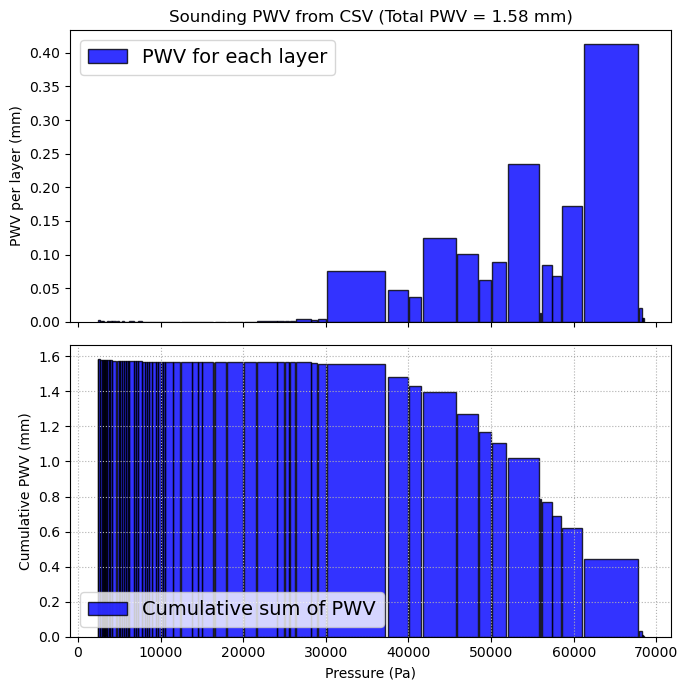

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- your original utilities (unchanged) ---
def PWV_array(rho, g, m_mix_kgkg, p_pa):
    """
    rho: water density (kg/m^3)
    g: gravity (m/s^2)
    m_mix_kgkg: mass mixing ratio of water vapor (kg/kg)
    p_pa: pressure (Pa)
    returns: (PWV_arr_per_layer_mm, PWV_total_mm)
    """
    PWV_arr = np.zeros(len(p_pa) - 1)
    PWV_sum = 0.0
    for i in range(len(p_pa) - 1):
        sum_m_P_rho = 0.5 * (m_mix_kgkg[i+1] + m_mix_kgkg[i]) * np.abs(p_pa[i+1] - p_pa[i])
        PWV_meter = sum_m_P_rho / (g * rho)      # m
        PWV_arr[i] = PWV_meter * 1000.0          # mm
        PWV_sum += PWV_arr[i]
    return PWV_arr, PWV_sum

def PWVCumuSum(PWV_arr):
    out = np.zeros(len(PWV_arr))
    out[0] = PWV_arr[0]
    for i in range(1, len(PWV_arr)):
        out[i] = out[i-1] + PWV_arr[i]
    return out

# ------------- new: read from CSV -------------
path = os.getcwd()
csv_path = os.path.join(path, "2024010100-89009.csv")  
g = 9.8
rho_w_liq = 1000.0  # kg/m^3

# read; tolerate comments and odd spacing
df = pd.read_csv(csv_path, comment="#", skip_blank_lines=True)
df.columns = [c.strip().upper() for c in df.columns]
#print(df.columns)

# minimal required columns
needed = {"PRESSURE_HPA", "MIXING RATIO_G/KG"}      

missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"CSV is missing required columns: {missing}. ")

# keep only rows with finite values
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=list(needed))

# Sort by pressure so adjacent rows are adjacent layers (doesn't matter which direction since we use |Δp|)
# Many soundings list from high P (surface) to low P (aloft); we'll sort descending to be explicit.
df = df.sort_values("PRESSURE_HPA", ascending=False).reset_index(drop=True)

# numpy arrays and unit conversions
p_hpa = df["PRESSURE_HPA"].to_numpy(dtype=float)
p_pa  = p_hpa * 100.0 # hPa to Pa
m_mix_gkg = df["MIXING RATIO_G/KG"].to_numpy(dtype=float)
m_mix_kgkg = m_mix_gkg * 1e-3

# midpoints for plotting
pa_mid = 0.5 * (p_pa[:-1] + p_pa[1:])
dp = np.abs(np.diff(p_pa))

# compute PWV per layer and cumulative/total
PWV_arr, PWV_sum = PWV_array(rho_w_liq, g, m_mix_kgkg, p_pa)
PWV_cumu = PWVCumuSum(PWV_arr)

# ------------- plotting (similar to your old layout) -------------
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

# bar for each layer's PWV (x = pressure midpoint, width = Δp)
axes[0].bar(pa_mid, PWV_arr, width=dp*0.95, alpha=0.8, edgecolor="k", color='b')
axes[0].set_ylabel("PWV per layer (mm)")
axes[0].set_title(f"Sounding PWV from CSV (Total PWV = {PWV_sum:.2f} mm)")

# cumulative
axes[1].bar(pa_mid, PWV_cumu, width=dp*0.95, alpha=0.8, edgecolor="k", color='b')
axes[1].set_ylabel("Cumulative PWV (mm)")
axes[1].set_xlabel("Pressure (Pa)")
axes[1].grid(True, ls=":")

axes[0].legend([f"PWV for each layer"], fontsize=14)
axes[1].legend([f"Cumulative sum of PWV"], fontsize=14, loc='lower left')

plt.tight_layout()
plt.show()


<class 'numpy.ndarray'>
<class 'int'>
<class 'numpy.ndarray'>


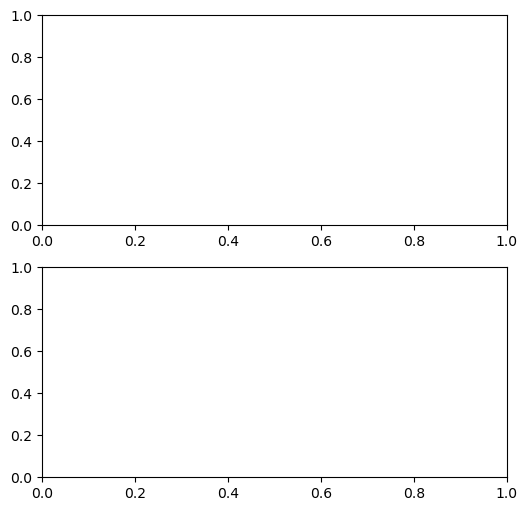

In [ ]:
import numpy as np
import os 
import matplotlib.pyplot as plt

# from pyrtlib.climatology import AtmosphericProfiles as atmp
# from pyrtlib.utils import ppmv2gkg, mr2rh
# from pyrtlib.tb_spectrum import TbCloudRTE

def PWV_array(rho,g,m_mix_kgkg,p_pa):
    """
    Calculate the precipitable water vapor from the mixing ratio.

    input:
        rho_w in kg/m^3
        g in m/s^2
        mass mixing ratio of water vapor in kg/kg
        pressure in Pa
        
    output:
        PWV(numpy.ndarray) in mm

    """
    PWV_arr = np.zeros(len(p_pa)-1)
    PWV_sum = 0
    
    for i in range(len(p_pa) - 1):
        sum_m_P_rho = 0.5 * (m_mix_kgkg[i+1] + m_mix_kgkg[i]) * np.abs(p_pa[i+1] - p_pa[i])
        #Use Trapezoidal rule
        PWV_meter = sum_m_P_rho / (g*rho) # in m
        PWV_arr[i] = PWV_meter * 1000 # convert to mm
        PWV_sum += PWV_arr[i]

    return PWV_arr, PWV_sum

def PWVCumuSum(PWV_arr):

    """
    Calculate the cumulative sum of the precipitable water vapor.

    input:
        PWV_arr in mm

    output:
        PWV_sum in mm

    """
    PWV_lay_sum = np.zeros(len(PWV_arr))
    PWV_lay_sum[0] = PWV_arr[0]

    for i in range(1,len(PWV_arr)):
        PWV_lay_sum[i] = PWV_arr[i] + PWV_lay_sum[i-1]

    return PWV_lay_sum

atms = [atmp.MIDLATITUDE_SUMMER]
g = 9.8 # m/s^2
colors = ['r', 'b', 'g', 'm']
cnt = 0
row = 0
col = 0

for atm in atms:
    fig0, ax0 = plt.subplots(2, 1, figsize=(6, 6))
    
    
    z, p, _, t, md = atmp.gl_atm(atm)
    md_H2O = md[:, atmp.H2O]
    p_pa = p * 1e2  # Convert to Pa

    # Calculate the pressure midpoints

    pa_mid = (p_pa[:-1] + p_pa[1:]) / 2  # Midpoints between pressure layers
    z_mid = (z[:-1] + z[1:]) / 2  # Midpoints between altitude layers
    
    m_mix_gkg = ppmv2gkg(md_H2O, atmp.H2O)
    m_mix_kgkg = m_mix_gkg * 1e-3

    rho_w_liq = 1000  # kg/m³
    print(type(m_mix_kgkg))
    print(type(rho_w_liq))
    print(type(p_pa))

    # PWV_arr, PWV_sum = PWV_array(rho_w_liq, g, m_mix_kgkg, p_pa)
    # PWV_sum = np.round(PWV_sum, 2)

#     PWV_cumu_sum = PWVCumuSum(PWV_arr)
    
    
#     for i in range(len(PWV_arr)):
        
#         dp = np.abs(p_pa[i] - p_pa[i+1])
        
#         if PWV_arr[i] > 1e-3:

#             ax0[0].bar(pa_mid[i], PWV_arr[i], width=dp, color=colors[cnt], alpha=0.5)  
#             ax0[1].bar(pa_mid[i], PWV_cumu_sum[i], width=dp, align='edge', color=colors[cnt], alpha=0.5)
            
#         else:
#             continue


#     ax0[0].set_ylabel('PWV (mm)', fontsize=14)
#     ax0[1].set_ylabel('Cumulative PWV (mm)', fontsize=14)

#     plt.xlabel("Pressure (Pa)", fontsize=14)
#     # and Altitude Midpoints

#     ax0[0].set_title(f"{atmp.atm_profiles()[atm]} (Total PWV: {PWV_sum} mm)", fontsize=14)
#     ax0[0].legend([f"PWV for each layer"], fontsize=14)
#     ax0[1].legend([f"Cumulative sum of PWV"], fontsize=14, loc='lower left')
#     plt.grid(True)
#     plt.savefig(f"PWV_{atmp.atm_profiles()[atm]} 0907.pdf")
#     plt.show()
#     cnt += 1

# plt.show()



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
pressure_pa = np.array([1e5, 8e4, 6e4, 4e4, 2e4])  # Primary x-axis (Pa)
altitude_km = np.array([0, 2, 4, 6, 8])             # Secondary x-axis (km)
y = [1, 2, 3, 2, 1]

fig, ax1 = plt.subplots()

# Primary x-axis (bottom)
ax1.set_xlabel("Pressure (Pa)", color="blue")
ax1.plot(pressure_pa, y, color="blue")
ax1.tick_params(axis='x', labelcolor="blue")

# Secondary x-axis (top)
ax2 = ax1.twiny()
ax2.set_xlabel("Altitude (km)", color="red")
ax2.set_xlim(ax1.get_xlim())  # Match x-limits of primary axis
ax2.set_xticks(pressure_pa)   # Align secondary ticks with primary
ax2.set_xticklabels(altitude_km)  # Map pressure to altitude labels
ax2.tick_params(axis='x', labelcolor="red")

plt.show()
